<a href="https://colab.research.google.com/github/Nikhil5566/Data-Science-Portfolio-Projects/blob/main/Sleep%20dataset_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sleep dataset

# About the dataset and Key-Insights::

---

This dataset required meticulous cleaning. Several crucial columns like max_life_span, gestation_time, and total_sleep were identified as object types due to the presence of '?' characters, which were correctly replaced with missing values (np.nan) and converted to a numerical format. Approximately 6.5% of the data points for these columns were missing, and these gaps were expertly filled using KNN imputation, a method chosen due to the observed correlations between features, ensuring more accurate estimations than simpler imputation techniques.

Exploratory Data Analysis (EDA) highlighted significant characteristics of the data. body_weight and brain_weight exhibited extreme right-skewness, a common trait in biological datasets spanning small mice to large elephants. This skewness was effectively addressed by applying log1p transformations, which normalized their distributions, making them more suitable for linear models. Outlier detection, using the IQR method, identified several extreme values, particularly in the body_weight, brain_weight, max_life_span, and gestation_time columns. Interestingly, total_sleep showed a relatively normal distribution.

Correlation analysis revealed important relationships. A comparison between Pearson and Spearman correlations indicated non-linear associations, especially between body_weight/brain_weight and max_life_span, underscoring the importance of considering non-linear models or transformations. A significant finding from hypothesis testing using the Kruskal-Wallis test was that total_sleep duration differs significantly across various danger_index levels (p-value < 0.001), suggesting that an animal's perceived danger directly influences its sleep habits.

Predictive modeling started with Multiple Linear Regression to predict total_sleep. After log-transforming body_weight and brain_weight, the model achieved an R-squared of 0.646. Gestation_time and danger_index emerged as statistically significant predictors. However, a Variance Inflation Factor (VIF) analysis revealed severe multicollinearity among predation_index, sleep_exposure_index, and danger_index, along with body_weight and brain_weight, indicating these variables convey redundant information and could destabilize the linear model. Residual diagnostics helped confirm the model's assumptions.

Logistic Regression was then employed to classify species as 'long sleepers' or 'short sleepers' based on their total_sleep duration relative to the median. Using 5-fold stratified cross-validation, the model demonstrated robust performance with an average accuracy of 75.9% and an impressive ROC-AUC of 87.1%. The classification report showed good precision and recall for both categories. Analysis of the model's coefficients (odds ratios) indicated predation_index had a positive association with being a long sleeper, while danger_index, gestation_time, and max_life_span had negative associations.

Finally, Principal Component Analysis (PCA) was used for dimensionality reduction and to address multicollinearity. The first two principal components captured approximately 88% of the total variance, effectively condensing the information from the original features. The loadings indicated that PC1 was heavily influenced by biological size-related variables (log_body_weight, log_brain_weight, gestation_time, sleep_exposure_index) while PC2 was primarily driven by ecological risk factors (predation_index, danger_index).

In summary, this analysis provides a deep understanding of the factors influencing sleep duration in mammals, highlighting the critical roles of physiological attributes and environmental dangers, while also showcasing robust statistical and machine learning techniques for handling complex, skewed biological data.

---

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')
from scipy import stats
from scipy.stats import shapiro, kruskal, pearsonr, spearmanr, zscore
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import (mean_squared_error, r2_score, roc_auc_score, roc_curve, confusion_matrix, classification_report)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [4]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d mathurinache/sleep-dataset

# Unziping the downloaded file
!unzip sleep-dataset.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/mathurinache/sleep-dataset
License(s): CC0-1.0
100% 0.98k/0.98k [00:00<00:00, 2.71MB/s]

Archive:  sleep-dataset.zip
  inflating: dataset_2191_sleep.csv  


In [5]:
df = pd.read_csv('dataset_2191_sleep.csv')
df.head(11)

,body_weight,brain_weight,max_life_span,gestation_time,predation_index,sleep_exposure_index,danger_index,total_sleep
0,6654.000,5712.0,38.6,645,3,5,3,3.3
1,1.000,6.6,4.5,42,3,1,3,8.3
2,3.385,44.5,14,60,1,1,1,12.5
3,0.920,5.7,?,25,5,2,3,16.5
4,2547.000,4603.0,69,624,3,5,4,3.9
5,10.550,179.5,27,180,4,4,4,9.8
6,0.023,0.3,19,35,1,1,1,19.7
7,160.000,169.0,30.4,392,4,5,4,6.2
8,3.300,25.6,28,63,1,2,1,14.5
9,52.160,440.0,50,230,1,1,1,9.7


In [6]:
df.tail(11)

,body_weight,brain_weight,max_life_span,gestation_time,predation_index,sleep_exposure_index,danger_index,total_sleep
51,3.600,21.0,6,225,3,2,3,5.4
52,14.830,98.2,17,150,5,5,5,2.6
53,55.500,175.0,20,151,5,5,5,3.8
54,1.400,12.5,12.7,90,2,2,2,11
55,0.060,1.0,3.5,?,3,1,2,10.3
56,0.900,2.6,4.5,60,2,1,2,13.3
57,2.000,12.3,7.5,200,3,1,3,5.4
58,0.104,2.5,2.3,46,3,2,2,15.8
59,4.190,58.0,24,210,4,3,4,10.3
60,3.500,3.9,3,14,2,1,1,19.4


In [7]:
df.shape

(62, 8)

In [8]:
df.columns

Index(['body_weight', 'brain_weight', 'max_life_span', 'gestation_time',
       'predation_index', 'sleep_exposure_index', 'danger_index',
       'total_sleep'],
      dtype='object')

In [9]:
df.dtypes

,0
body_weight,float64
brain_weight,float64
max_life_span,object
gestation_time,object
predation_index,int64
sleep_exposure_index,int64
danger_index,int64
total_sleep,object


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   body_weight           62 non-null     float64
 1   brain_weight          62 non-null     float64
 2   max_life_span         62 non-null     object 
 3   gestation_time        62 non-null     object 
 4   predation_index       62 non-null     int64  
 5   sleep_exposure_index  62 non-null     int64  
 6   danger_index          62 non-null     int64  
 7   total_sleep           62 non-null     object 
dtypes: float64(2), int64(3), object(3)
memory usage: 4.0+ KB


In [11]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
body_weight,62.0,NaN,NaN,NaN,198.789984,899.158011,0.005,0.6,3.3425,48.2025,6654.0
brain_weight,62.0,NaN,NaN,NaN,283.134194,930.278942,0.14,4.25,17.25,166.0,5712.0
max_life_span,62,48,?,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gestation_time,62,50,?,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
predation_index,62.0,NaN,NaN,NaN,2.870968,1.476414,1.0,2.0,3.0,4.0,5.0
sleep_exposure_index,62.0,NaN,NaN,NaN,2.419355,1.604792,1.0,1.0,2.0,4.0,5.0
danger_index,62.0,NaN,NaN,NaN,2.612903,1.441252,1.0,1.0,2.0,4.0,5.0
total_sleep,62,45,?,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
df.isnull().sum()

,0
body_weight,0
brain_weight,0
max_life_span,0
gestation_time,0
predation_index,0
sleep_exposure_index,0
danger_index,0
total_sleep,0


In [13]:
df.duplicated().sum()

np.int64(0)

# Data Cleaning: Converting Object Type Columns to Numeric

From the `df.info()` and `df.dtypes` outputs, we observed that `max_life_span`, `gestation_time`, and `total_sleep` columns are of `object` type. Inspection of `df.head()` and `df.tail()` revealed that these columns contain '?' values, which prevent them from being correctly interpreted as numerical.

To prepare these columns for further analysis, we need to:
1.  Replace '?' with `np.nan` (Not a Number).
2.  Convert the columns to a numeric data type (e.g., `float`).

In [14]:
# List of columns to convert
MissingValues = ['max_life_span', 'gestation_time', 'total_sleep']

# Replace '?' with NaN and convert to numeric
for col in MissingValues:
    df[col] = df[col].replace('?', np.nan)
    df[col] = pd.to_numeric(df[col])

# Display the updated data types and info to confirm the changes
print("Updated dtypes:")
print(df[MissingValues].dtypes)
print("\nUpdated info:")
df.info()

Updated dtypes:
max_life_span     float64
gestation_time    float64
total_sleep       float64
dtype: object

Updated info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   body_weight           62 non-null     float64
 1   brain_weight          62 non-null     float64
 2   max_life_span         58 non-null     float64
 3   gestation_time        58 non-null     float64
 4   predation_index       62 non-null     int64  
 5   sleep_exposure_index  62 non-null     int64  
 6   danger_index          62 non-null     int64  
 7   total_sleep           58 non-null     float64
dtypes: float64(5), int64(3)
memory usage: 4.0 KB


# Univariate Analysis

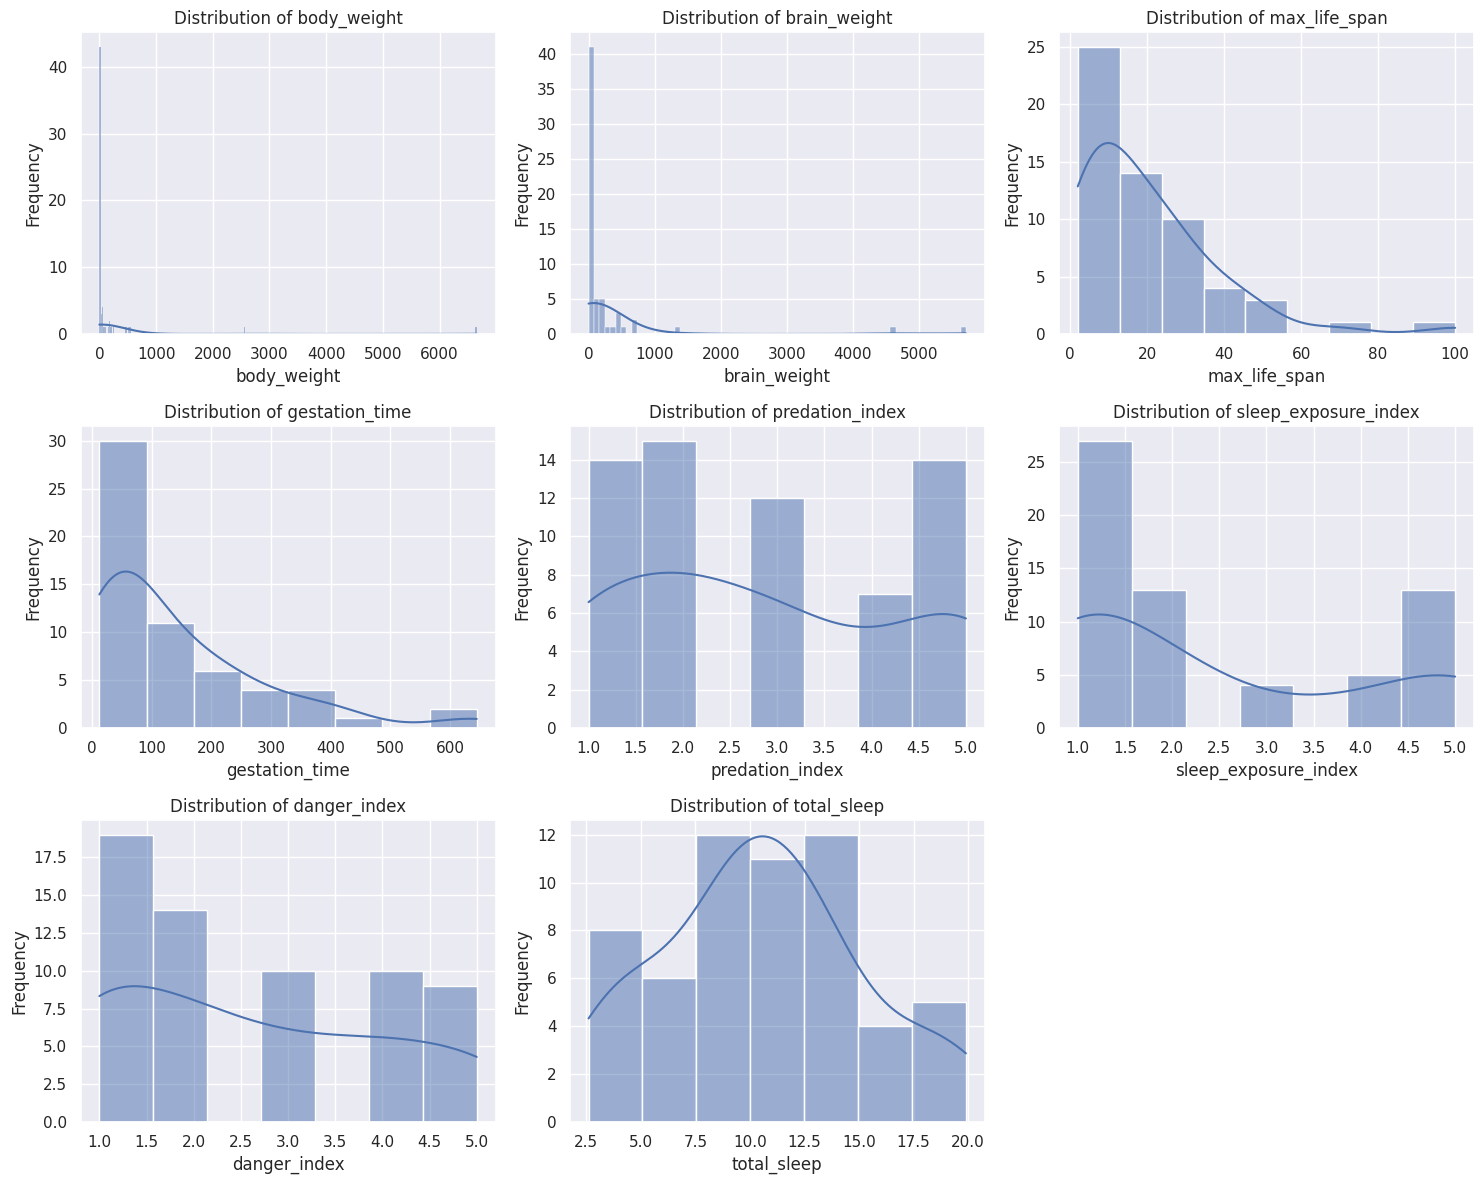

No categorical columns found.


In [15]:
import math
# --- 1. Numerical Columns (Histograms in a Grid) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numerical_cols) > 0:
    # Define grid size
    num_plots = len(numerical_cols)
    num_cols = 3  # You can change this to 2 or 4 if preferred
    num_rows = math.ceil(num_plots / num_cols)

    # Create figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()  # Flatten to 1D array for easy iteration

    # Iterate and plot
    for i, col in enumerate(numerical_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    # Hidding any unused subplots (if total plots < grid cells)
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found.")


# --- 2. Categorical Columns (Countplots in a Grid) ---
categorical_cols = df.select_dtypes(include='object').columns.tolist()

if len(categorical_cols) > 0:
    # Define grid size
    num_plots = len(categorical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Create figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterate and plot
    for i, col in enumerate(categorical_cols):
        sns.countplot(data=df, x=col, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

    # --- 3. Value Counts (Text Output) ---
    print("--- Categorical Value Counts ---")
    for col in categorical_cols:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts())
else:
    print("No categorical columns found.")

# Bivariate Analysis

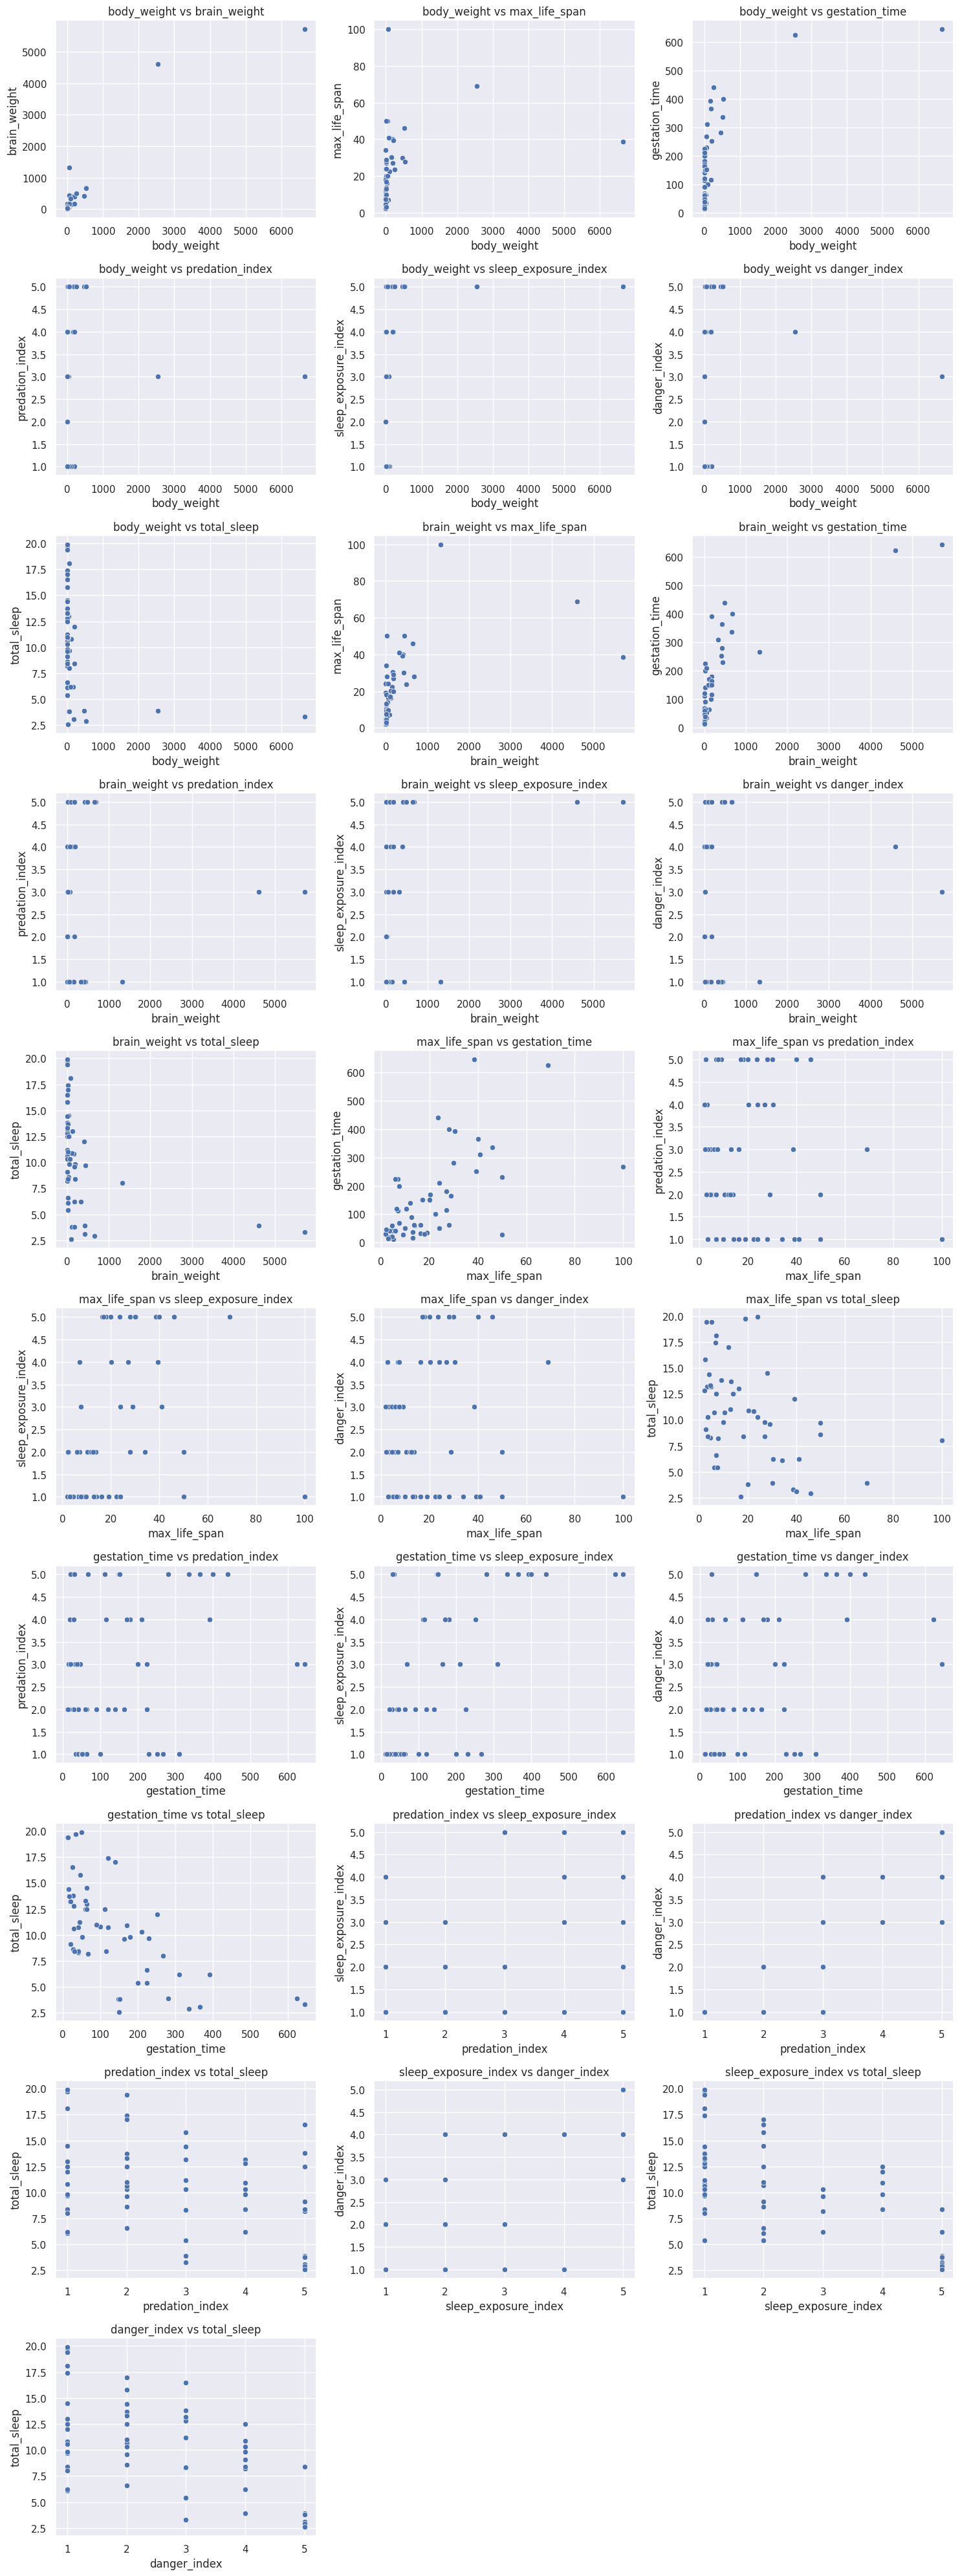

No categorical-numerical pairs found.


In [16]:
import itertools

# --- 1. Numerical-Numerical Relationships (Scatter Plots) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generate all unique pairs of numerical columns
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(num_pairs) > 0:
    # Define grid size
    num_plots = len(num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Create figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    # Flatten axes for easy iteration.
    # Handle edge case where there is only 1 plot (axes is not an array)
    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterate through pairs and plot
    for i, (col1, col2) in enumerate(num_pairs):
        sns.scatterplot(data=df, x=col1, y=col2, ax=axes[i])
        axes[i].set_title(f'{col1} vs {col2}')
        axes[i].set_xlabel(col1)
        axes[i].set_ylabel(col2)

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns for scatter plots.")


# --- 2. Categorical-Numerical Relationships (Box Plots) ---
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generate all pairs of (Categorical, Numerical)
cat_num_pairs = list(itertools.product(categorical_cols, numerical_cols))

if len(cat_num_pairs) > 0:
    # Define grid size
    num_plots = len(cat_num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Create figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterate through pairs and plot
    for i, (cat_col, num_col) in enumerate(cat_num_pairs):
        # 1. Get top 10 categories based on frequency
        top_categories = df[cat_col].value_counts().nlargest(10).index.tolist()

        # 2. Filter data: Keep only top categories AND ensure numerical column is not NaN
        filtered_df = df[df[cat_col].isin(top_categories) & df[num_col].notnull()]

        # 3. Update 'order' to only include categories that exist in the filtered data
        # This prevents the ValueError where a category in 'order' has no data to plot
        valid_categories = [cat for cat in top_categories if cat in filtered_df[cat_col].unique()]

        if valid_categories:
            sns.boxplot(data=filtered_df, x=cat_col, y=num_col, ax=axes[i], order=valid_categories)
            axes[i].set_title(f'{num_col} by {cat_col} (Top 10)')
            axes[i].set_xlabel(cat_col)
            axes[i].set_ylabel(num_col)
            axes[i].tick_params(axis='x', rotation=45)
        else:
             axes[i].text(0.5, 0.5, "No valid data", ha='center', va='center')

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No categorical-numerical pairs found.")

# Multivariate Analysis

--- 1. MULTIVARIATE: Predation Index Composition by Other Indices ---


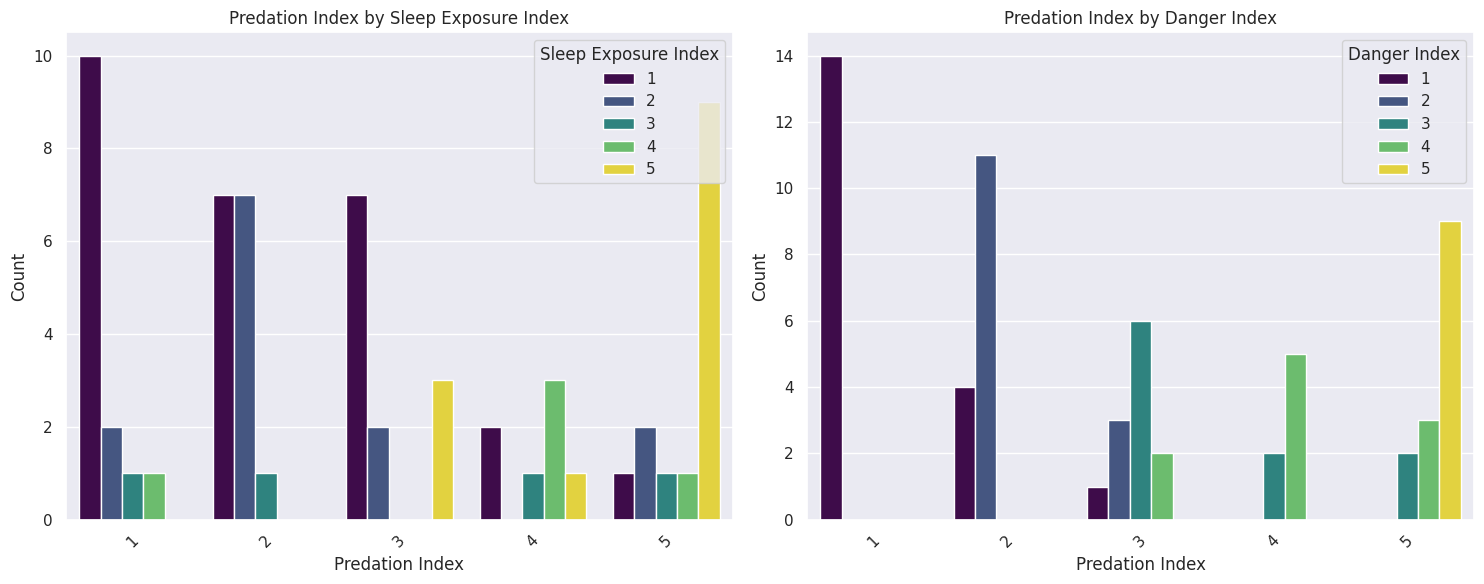


--- 2. MULTIVARIATE: NUMERICAL RELATIONSHIPS (Scatterplots) ---


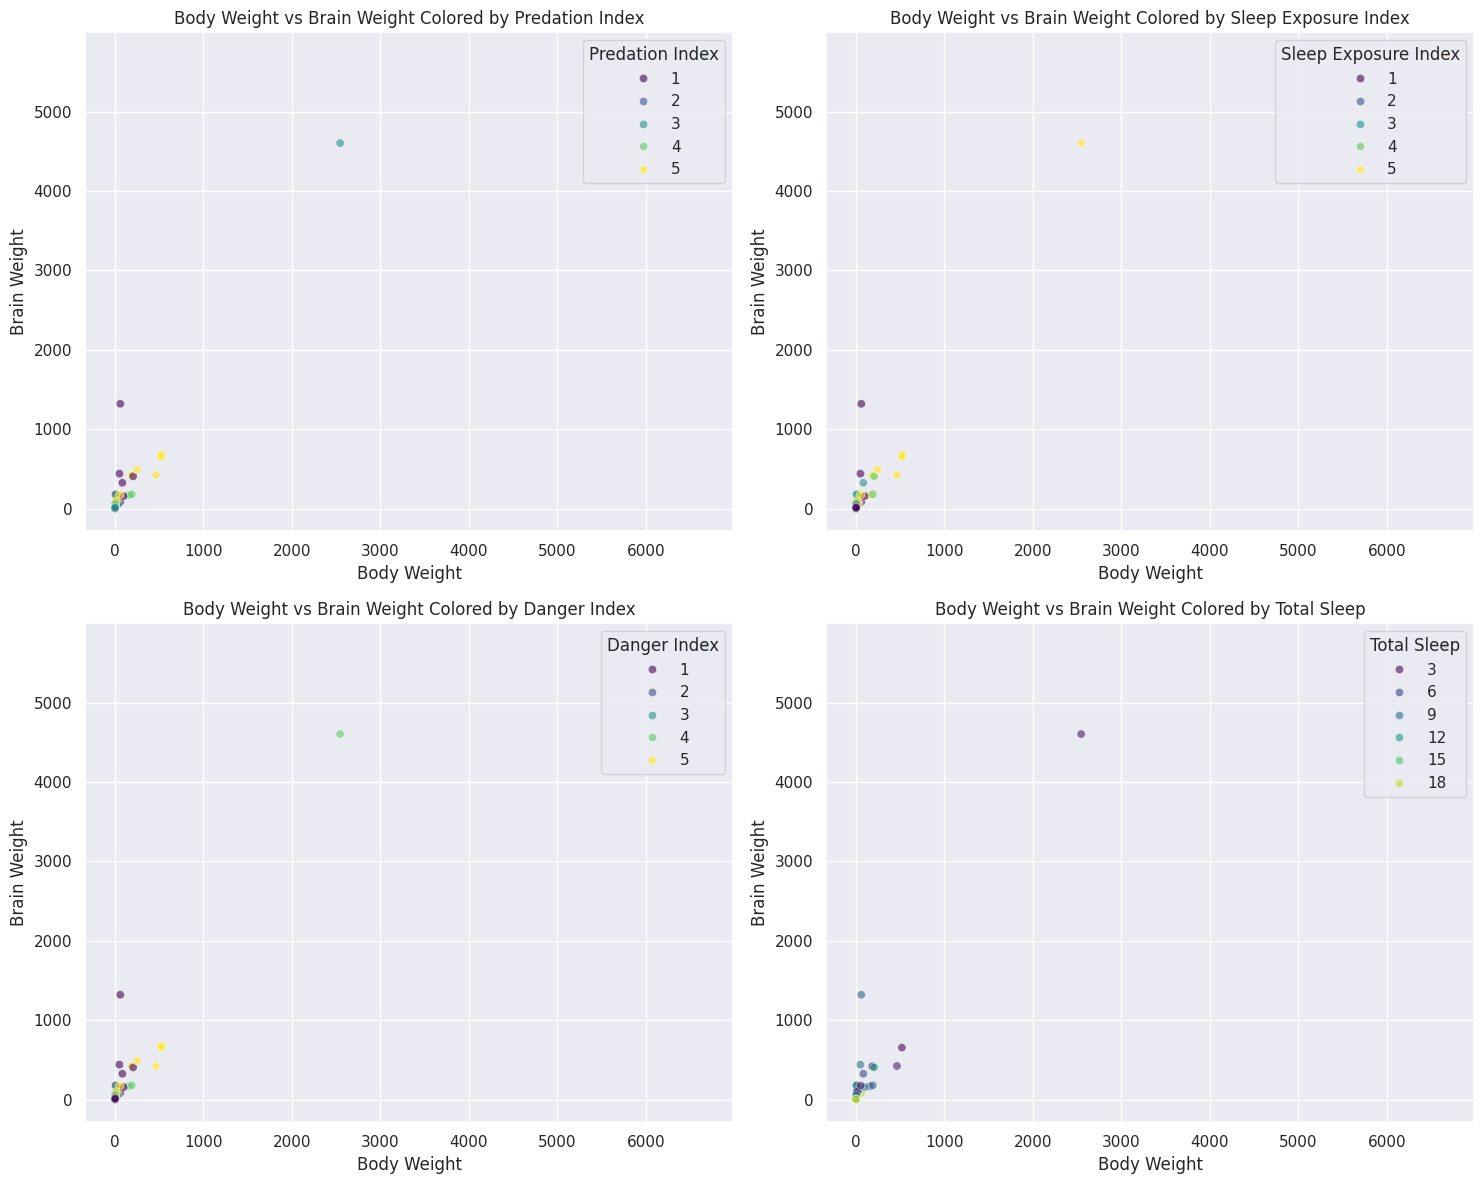

In [17]:
import math

# --- 1. MULTIVARIATE: CATEGORICAL RELATIONSHIPS (Countplots) ---

# Use categorical-like index columns for meaningful countplots
x_countplot = 'predation_index'
hue_countplot_cols = ['sleep_exposure_index', 'danger_index']

print(f"--- 1. MULTIVARIATE: {x_countplot.replace('_', ' ').title()} Composition by Other Indices ---")

num_plots = len(hue_countplot_cols)
num_cols = 2
num_rows = math.ceil(num_plots / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 6 * num_rows))
axes = axes.flatten()

for i, col in enumerate(hue_countplot_cols):
    sns.countplot(data=df, x=x_countplot, hue=col, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{x_countplot.replace("_", " ").title()} by {col.replace("_", " ").title()}')
    axes[i].set_xlabel(x_countplot.replace('_', ' ').title())
    axes[i].set_ylabel('Count')
    axes[i].legend(loc='upper right', bbox_to_anchor=(1, 1), title=col.replace('_', ' ').title())
    axes[i].tick_params(axis='x', rotation=45)

# Hiding unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


print("\n--- 2. MULTIVARIATE: NUMERICAL RELATIONSHIPS (Scatterplots) ---")

# Define x and y for scatterplot
x_scatterplot = 'body_weight'
y_scatterplot = 'brain_weight'

# Define hue columns, including numerical for gradient effect and categorical-like
hue_scatterplot_cols = ['predation_index', 'sleep_exposure_index', 'danger_index', 'total_sleep']

num_plots = len(hue_scatterplot_cols)
num_cols = 2
num_rows = math.ceil(num_plots / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 6 * num_rows))
axes = axes.flatten()

for i, col in enumerate(hue_scatterplot_cols):
    sns.scatterplot(data=df, x=x_scatterplot, y=y_scatterplot, hue=col, ax=axes[i], palette='viridis', alpha=0.6)
    axes[i].set_title(f'{x_scatterplot.replace("_", " ").title()} vs {y_scatterplot.replace("_", " ").title()} Colored by {col.replace("_", " ").title()}')
    axes[i].set_xlabel(x_scatterplot.replace('_', ' ').title())
    axes[i].set_ylabel(y_scatterplot.replace('_', ' ').title())
    # Move legend outside if too crowded
    axes[i].legend(loc='upper right', title=col.replace('_', ' ').title())

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# Pair-Plot

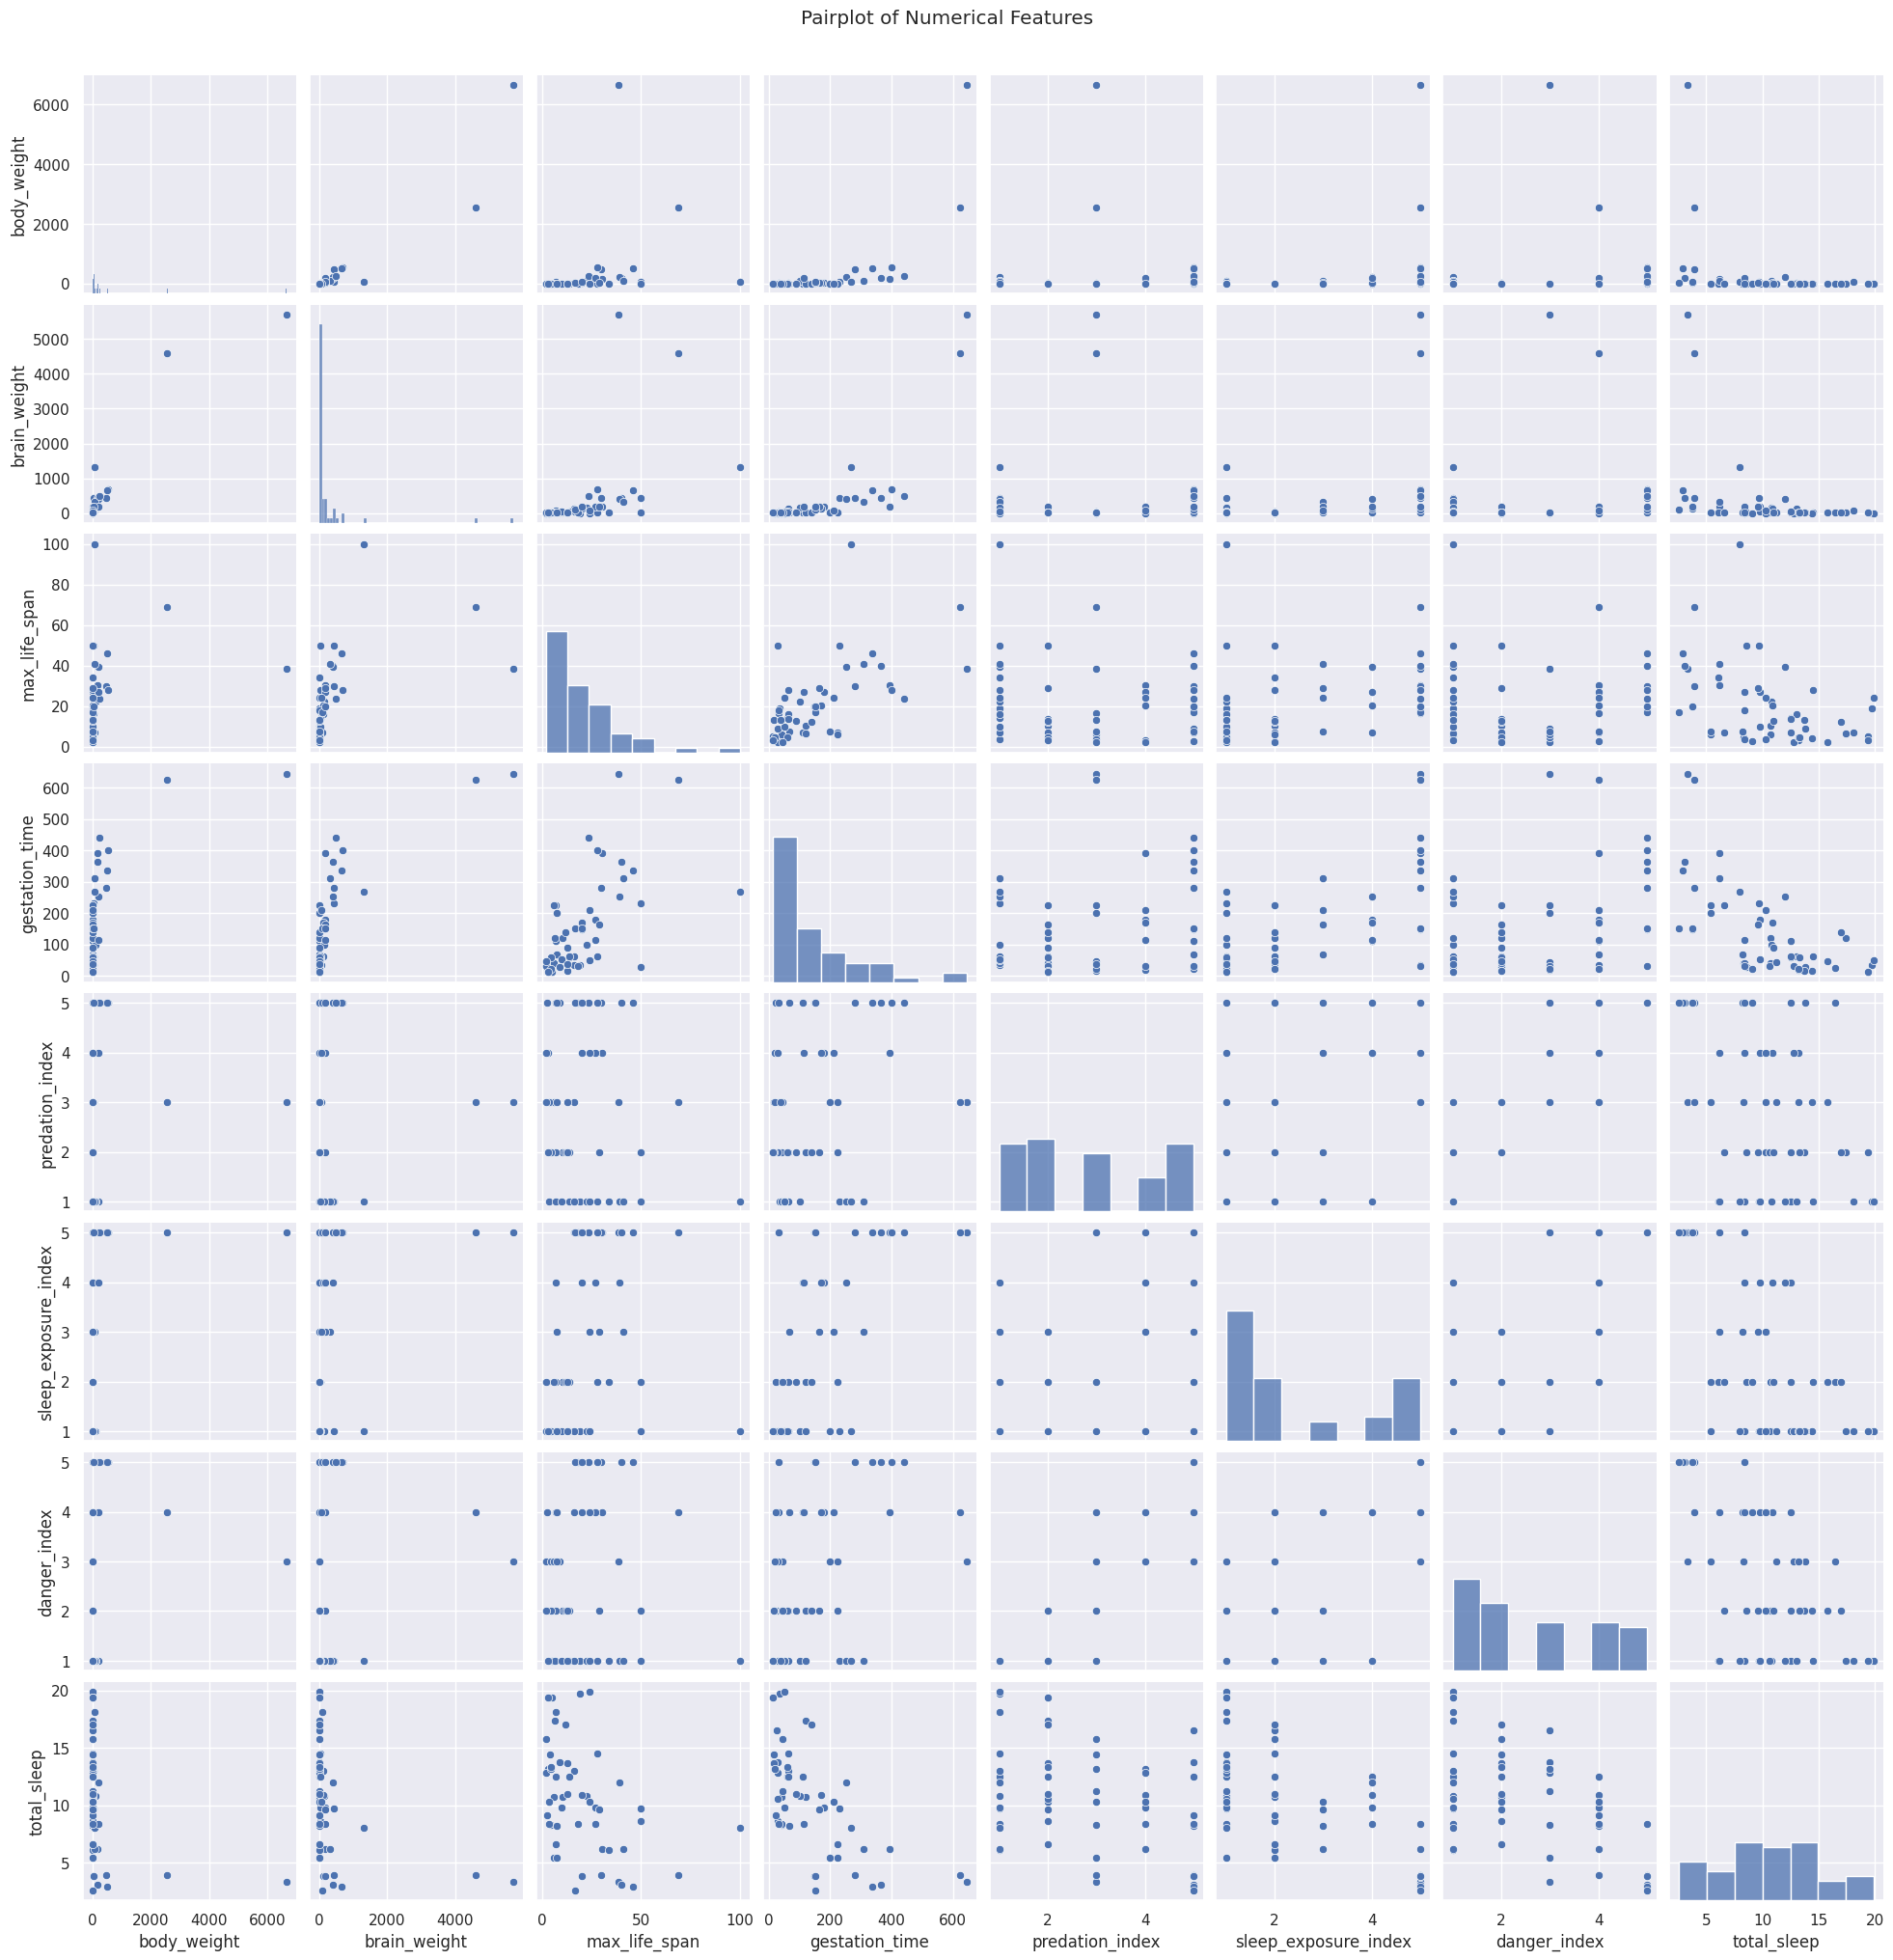

In [18]:
sns.pairplot(df.select_dtypes(include = np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

# Heatmap

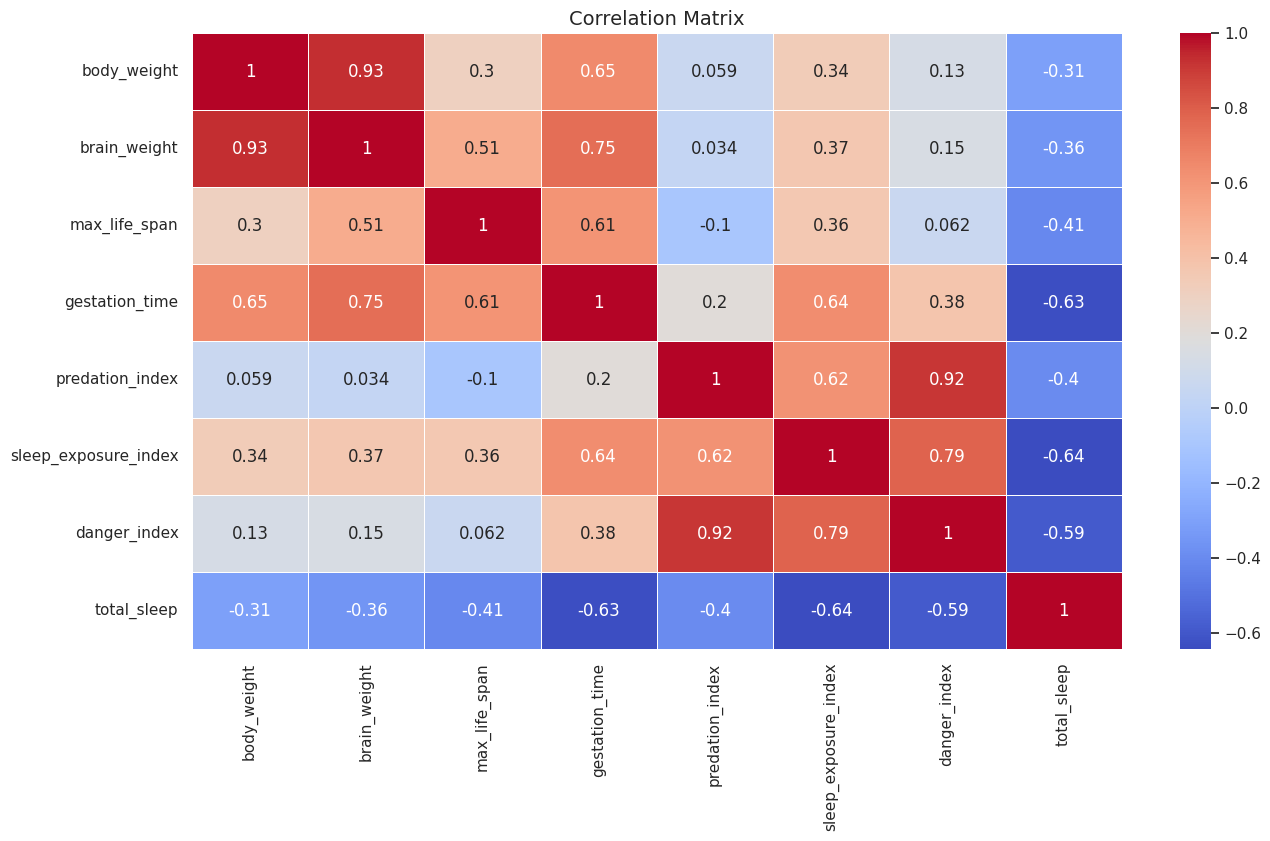

In [19]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# ADVANCED STATISTICAL ANALYSIS — Mammal Sleep Dataset (62 species, 8 vars)
Continues the notebook's EDA section into full inferential + predictive
statistics, matching a standard analyst/DS interview pipeline:

  1. Clean + missing-data diagnostics
  2. Distribution shape (skew/kurtosis, normality tests)
  3. Outlier detection (IQR + Z-score)
  4. Missing-value imputation (KNN, since features are correlated)
  5. Correlation analysis (Pearson vs Spearman — dataset is skewed)
  6. Hypothesis testing (Kruskal-Wallis: does total_sleep differ by danger group?)
  7. Multiple linear regression (predict total_sleep) + VIF + residual diagnostics
  8. Logistic regression (classify high vs low sleepers) + k-fold CV + ROC
  9. PCA (dimensionality reduction / multicollinearity check)

Dataset background (useful to know for interviews):
  predation_index, sleep_exposure_index, danger_index are ORDINAL 1-5
  ratings (not raw continuous measurements) from Allison & Cicchetti (1976).
  body_weight/brain_weight are heavily right-skewed (mice to elephants),
  so log-transforms and rank-based (Spearman) stats matter here.


# 1. Statistical Analysis

In [21]:
for col in ['max_life_span', 'gestation_time', 'total_sleep']:
    df[col] = pd.to_numeric(df[col].replace('?', np.nan))

print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nMissing %:\n", (df.isnull().mean() * 100).round(1))

num_cols = df.select_dtypes(include=np.number).columns.tolist()

Shape: (62, 8)

Missing values:
 body_weight             0
brain_weight            0
max_life_span           4
gestation_time          4
predation_index         0
sleep_exposure_index    0
danger_index            0
total_sleep             4
dtype: int64

Missing %:
 body_weight             0.0
brain_weight            0.0
max_life_span           6.5
gestation_time          6.5
predation_index         0.0
sleep_exposure_index    0.0
danger_index            0.0
total_sleep             6.5
dtype: float64


# 2. DISTRIBUTION SHAPE — skew, kurtosis, normality


=== Distribution shape ===
                       skew  kurtosis  shapiro_p  likely_normal (p>0.05)
body_weight           6.564    45.741       0.00                   False
brain_weight          5.072    26.271       0.00                   False
max_life_span         2.014     5.885       0.00                   False
gestation_time        1.684     2.852       0.00                   False
predation_index       0.230    -1.329       0.00                   False
sleep_exposure_index  0.680    -1.195       0.00                   False
danger_index          0.378    -1.225       0.00                   False
total_sleep           0.201    -0.508       0.14                    True


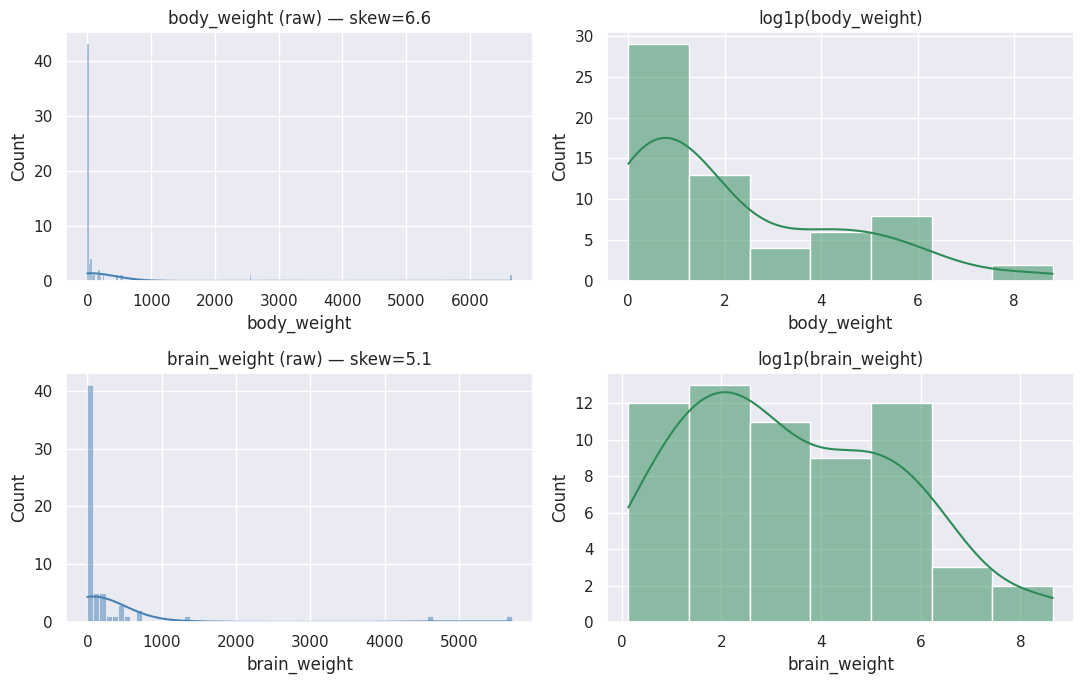

In [25]:
shape_summary = pd.DataFrame({
    'skew': df[num_cols].skew(),
    'kurtosis': df[num_cols].kurt(),
    'shapiro_p': [shapiro(df[c].dropna())[1] for c in num_cols]
})
shape_summary['likely_normal (p>0.05)'] = shape_summary['shapiro_p'] > 0.05
print("\n=== Distribution shape ===")
print(shape_summary.round(3))

# body_weight / brain_weight are classically extreme (mouse vs elephant) —
# visualize raw vs log to show WHY we'll log-transform them for modeling
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
sns.histplot(df['body_weight'].dropna(), kde=True, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('body_weight (raw) — skew=%.1f' % df['body_weight'].skew())
sns.histplot(np.log1p(df['body_weight'].dropna()), kde=True, ax=axes[0, 1], color='seagreen')
axes[0, 1].set_title('log1p(body_weight)')
sns.histplot(df['brain_weight'].dropna(), kde=True, ax=axes[1, 0], color='steelblue')
axes[1, 0].set_title('brain_weight (raw) — skew=%.1f' % df['brain_weight'].skew())
sns.histplot(np.log1p(df['brain_weight'].dropna()), kde=True, ax=axes[1, 1], color='seagreen')
axes[1, 1].set_title('log1p(brain_weight)')
plt.tight_layout()
plt.savefig('01_distribution_log_transform.png')
plt.show()

# 3. OUTLIER DETECTION — IQR method + Z-score, side by side


=== IQR outlier counts per column ===
body_weight: 10 outlier(s)
brain_weight: 9 outlier(s)
max_life_span: 2 outlier(s)
gestation_time: 2 outlier(s)
predation_index: 0 outlier(s)
sleep_exposure_index: 0 outlier(s)
danger_index: 0 outlier(s)
total_sleep: 0 outlier(s)


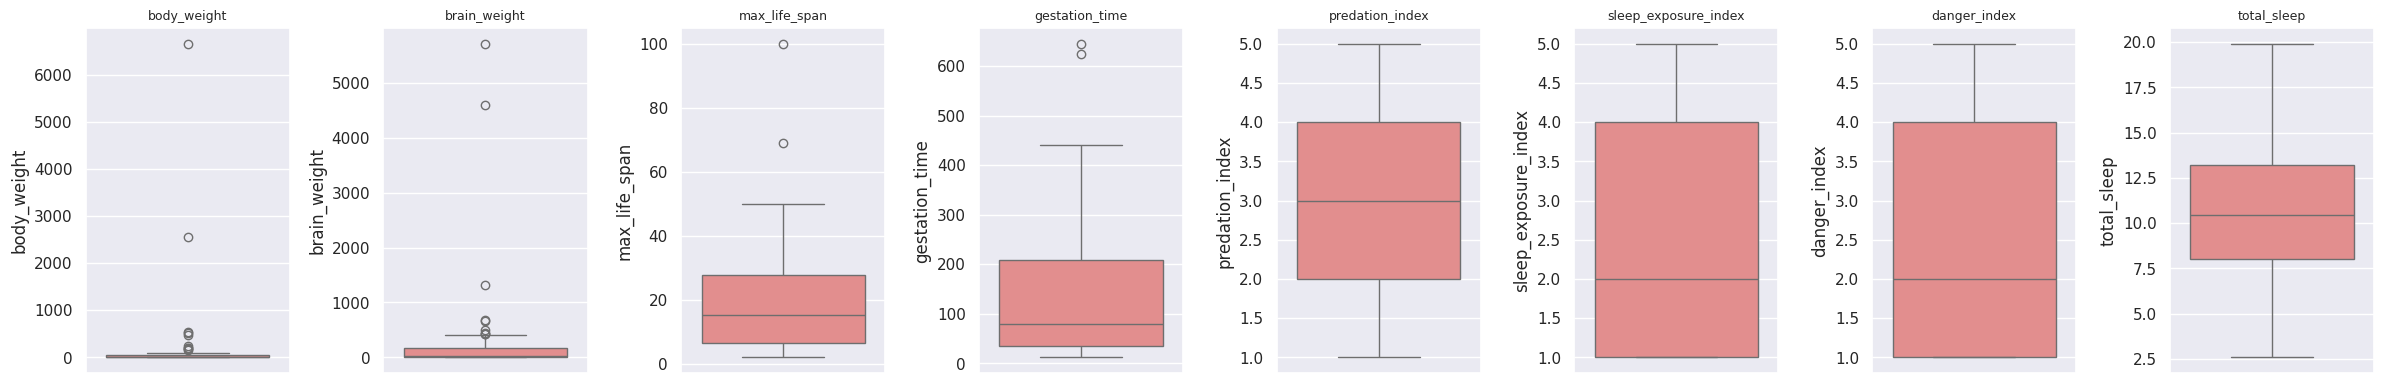

In [26]:
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return series[(series < lower) | (series > upper)]

print("\n=== IQR outlier counts per column ===")
for c in num_cols:
    out = iqr_outliers(df[c].dropna())
    print(f"{c}: {len(out)} outlier(s)")

fig, axes = plt.subplots(1, len(num_cols), figsize=(3 * len(num_cols), 4))
for ax, c in zip(axes, num_cols):
    sns.boxplot(y=df[c], ax=ax, color='lightcoral')
    ax.set_title(c, fontsize=9)
plt.tight_layout()
plt.savefig('02_boxplots_outliers.png')
plt.show()

# 4. MISSING-VALUE IMPUTATION — KNN
(better than median here since life span / gestation / sleep are correlated with body & brain weight)

In [27]:
scaler_impute = StandardScaler()
scaled = scaler_impute.fit_transform(df[num_cols])
imputer = KNNImputer(n_neighbors=5)
scaled_imputed = imputer.fit_transform(scaled)
df_imputed = df.copy()
df_imputed[num_cols] = scaler_impute.inverse_transform(scaled_imputed)

print("\nMissing values after KNN imputation:", df_imputed[num_cols].isnull().sum().sum())


Missing values after KNN imputation: 0


# 5. CORRELATION — Pearson vs Spearman

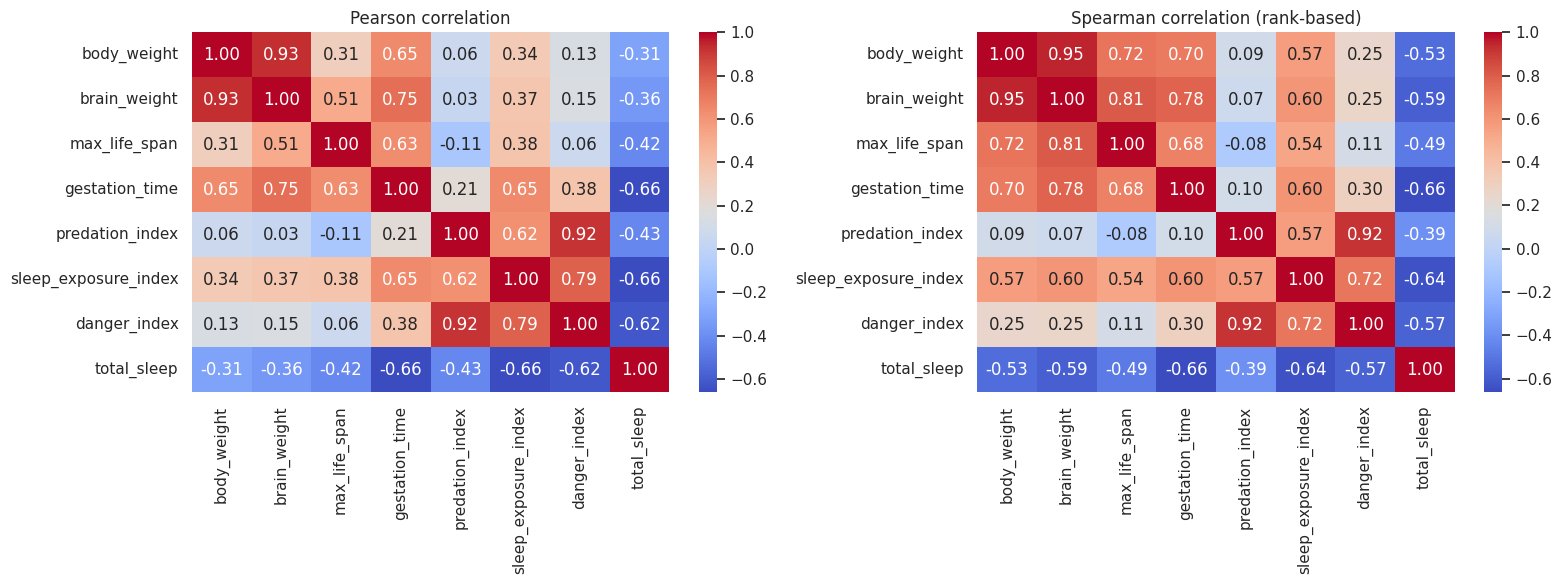


Biggest Pearson/Spearman gaps (possible nonlinear relationships):
body_weight           max_life_span           0.417045
max_life_span         brain_weight            0.295126
body_weight           sleep_exposure_index    0.232809
sleep_exposure_index  brain_weight            0.232515
body_weight           total_sleep             0.226351
total_sleep           brain_weight            0.223782
dtype: float64


In [28]:
pearson_corr = df_imputed[num_cols].corr(method='pearson')
spearman_corr = df_imputed[num_cols].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(pearson_corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0])
axes[0].set_title('Pearson correlation')
sns.heatmap(spearman_corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1])
axes[1].set_title('Spearman correlation (rank-based)')
plt.tight_layout()
plt.savefig('03_correlation_pearson_vs_spearman.png')
plt.show()

# where do the two methods disagree meaningfully? (flags nonlinear relationships)
diff = (pearson_corr - spearman_corr).abs()
print("\nBiggest Pearson/Spearman gaps (possible nonlinear relationships):")
print(diff.unstack().sort_values(ascending=False).drop_duplicates().head(6))

# 6. HYPOTHESIS TESTING


=== Kruskal-Wallis: total_sleep by danger_index ===
H = 24.677, p = 0.0001
-> Reject H0: sleep duration differs across danger levels


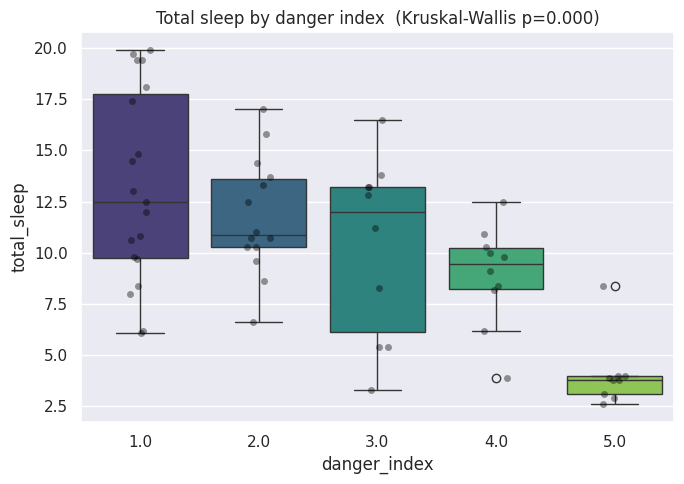

In [29]:
groups = [g['total_sleep'].dropna().values for _, g in df_imputed.groupby('danger_index')]
h_stat, p_val = kruskal(*groups)
print(f"\n=== Kruskal-Wallis: total_sleep by danger_index ===")
print(f"H = {h_stat:.3f}, p = {p_val:.4f}")
print("-> " + ("Reject H0: sleep duration differs across danger levels"
                if p_val < 0.05 else
                "Fail to reject H0: no significant difference detected"))

plt.figure(figsize=(7, 5))
sns.boxplot(data=df_imputed, x='danger_index', y='total_sleep', palette='viridis')
sns.stripplot(data=df_imputed, x='danger_index', y='total_sleep', color='black', alpha=0.4)
plt.title(f'Total sleep by danger index  (Kruskal-Wallis p={p_val:.3f})')
plt.tight_layout()
plt.savefig('04_kruskal_danger_vs_sleep.png')
plt.show()

# 7. MULTIPLE LINEAR REGRESSION — predict total_sleep, Log-transform the two skewed predictors first.

In [30]:
model_df = df_imputed.copy()
model_df['log_body_weight'] = np.log1p(model_df['body_weight'])
model_df['log_brain_weight'] = np.log1p(model_df['brain_weight'])

predictors = ['log_body_weight', 'log_brain_weight', 'max_life_span',
              'gestation_time', 'predation_index', 'sleep_exposure_index', 'danger_index']
X = model_df[predictors]
y = model_df['total_sleep']

X_sm = sm.add_constant(X)
ols_model = sm.OLS(y, X_sm).fit()
print("\n=== OLS Regression Summary ===")
print(ols_model.summary())


=== OLS Regression Summary ===
                            OLS Regression Results                            
Dep. Variable:            total_sleep   R-squared:                       0.646
Model:                            OLS   Adj. R-squared:                  0.600
Method:                 Least Squares   F-statistic:                     14.08
Date:                Thu, 23 Jul 2026   Prob (F-statistic):           3.11e-10
Time:                        20:11:41   Log-Likelihood:                -150.41
No. Observations:                  62   AIC:                             316.8
Df Residuals:                      54   BIC:                             333.8
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------



=== Variance Inflation Factors (>5 = concerning, >10 = serious) ===
                feature        VIF
6          danger_index  52.537983
4       predation_index  32.804033
1      log_brain_weight  23.542980
5  sleep_exposure_index  17.524224
0       log_body_weight  14.342793
3        gestation_time   6.613858
2         max_life_span   5.502076


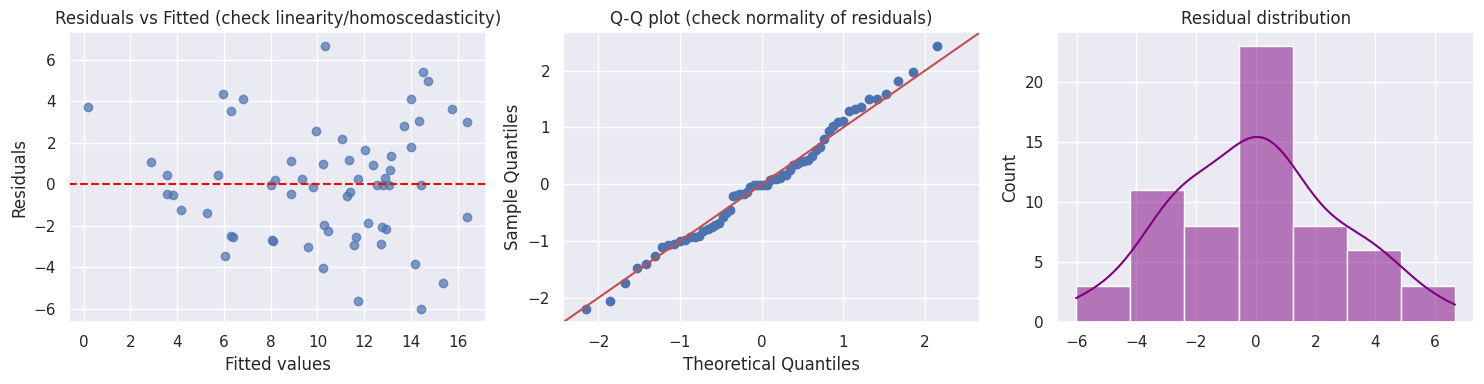

In [31]:
# VIF — check multicollinearity (predation/exposure/danger are related by construction)
vif_df = pd.DataFrame({
    'feature': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print("\n=== Variance Inflation Factors (>5 = concerning, >10 = serious) ===")
print(vif_df.sort_values('VIF', ascending=False))

# Residual diagnostics
fitted = ols_model.fittedvalues
resid = ols_model.resid

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(fitted, resid, alpha=0.7)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted values'); axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted (check linearity/homoscedasticity)')

sm.qqplot(resid, line='45', fit=True, ax=axes[1])
axes[1].set_title('Q-Q plot (check normality of residuals)')

sns.histplot(resid, kde=True, ax=axes[2], color='purple')
axes[2].set_title('Residual distribution')
plt.tight_layout()
plt.savefig('05_ols_residual_diagnostics.png')
plt.show()

# 8. LOGISTIC REGRESSION + K-FOLD CROSS-VALIDATION


=== Logistic Regression — 5-fold Stratified CV ===
Accuracy: 0.759 (+/- 0.148) per fold: [0.923 0.538 0.75  0.917 0.667]
ROC-AUC:  0.871 (+/- 0.112) per fold: [1.    0.81  0.944 0.917 0.686]

=== Out-of-fold classification report ===
               precision    recall  f1-score   support

short_sleeper       0.82      0.62      0.71        29
 long_sleeper       0.72      0.88      0.79        33

     accuracy                           0.76        62
    macro avg       0.77      0.75      0.75        62
 weighted avg       0.77      0.76      0.75        62



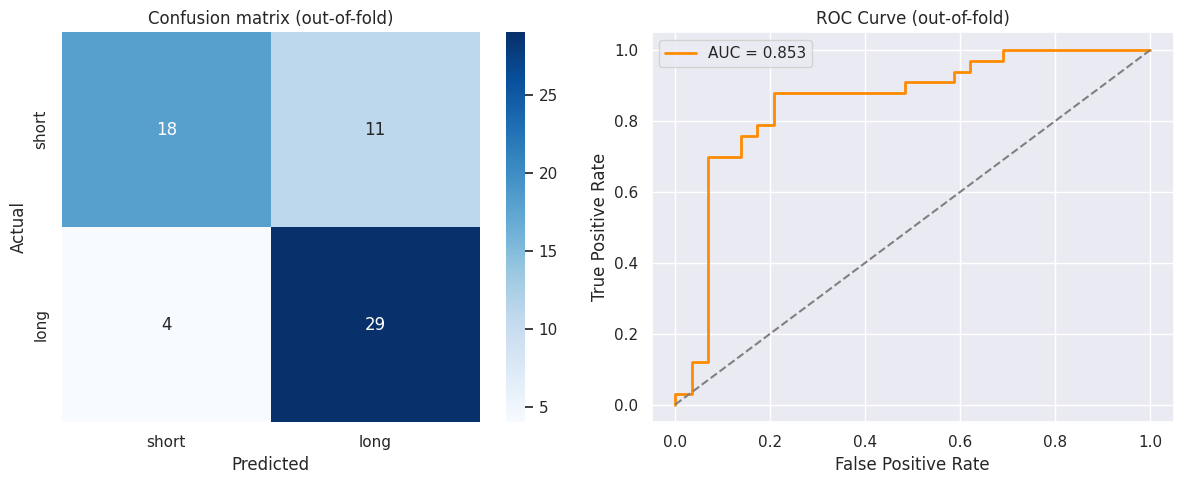

In [32]:
model_df['long_sleeper'] = (model_df['total_sleep'] >= model_df['total_sleep'].median()).astype(int)

X_clf = model_df[predictors]
y_clf = model_df['long_sleeper']

scaler = StandardScaler()
X_clf_scaled = scaler.fit_transform(X_clf)

clf = LogisticRegression(max_iter=1000)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_acc = cross_val_score(clf, X_clf_scaled, y_clf, cv=cv, scoring='accuracy')
cv_auc = cross_val_score(clf, X_clf_scaled, y_clf, cv=cv, scoring='roc_auc')

print(f"\n=== Logistic Regression — 5-fold Stratified CV ===")
print(f"Accuracy: {cv_acc.mean():.3f} (+/- {cv_acc.std():.3f}) per fold: {np.round(cv_acc, 3)}")
print(f"ROC-AUC:  {cv_auc.mean():.3f} (+/- {cv_auc.std():.3f}) per fold: {np.round(cv_auc, 3)}")

# Out-of-fold predictions for a proper (non-overfit) confusion matrix / classification report
y_pred_cv = cross_val_predict(clf, X_clf_scaled, y_clf, cv=cv)
y_proba_cv = cross_val_predict(clf, X_clf_scaled, y_clf, cv=cv, method='predict_proba')[:, 1]

print("\n=== Out-of-fold classification report ===")
print(classification_report(y_clf, y_pred_cv, target_names=['short_sleeper', 'long_sleeper']))

fpr, tpr, _ = roc_curve(y_clf, y_proba_cv)
auc_oof = roc_auc_score(y_clf, y_proba_cv)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_clf, y_pred_cv), annot=True, fmt='d', cmap='Blues',
            xticklabels=['short', 'long'], yticklabels=['short', 'long'], ax=axes[0])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion matrix (out-of-fold)')

axes[1].plot(fpr, tpr, label=f'AUC = {auc_oof:.3f}', color='darkorange', lw=2)
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (out-of-fold)')
axes[1].legend()
plt.tight_layout()
plt.savefig('06_logistic_cv_roc.png')
plt.show()

In [33]:
# Refit on full data just to inspect coefficient DIRECTION (odds ratios)
clf.fit(X_clf_scaled, y_clf)
coef_df = pd.DataFrame({
    'feature': predictors,
    'coef': clf.coef_[0],
    'odds_ratio': np.exp(clf.coef_[0])
}).sort_values('odds_ratio', ascending=False)
print("\n=== Logistic regression coefficients (standardized features) ===")
print(coef_df)


=== Logistic regression coefficients (standardized features) ===
                feature      coef  odds_ratio
4       predation_index  0.242998    1.275067
0       log_body_weight  0.008841    1.008880
5  sleep_exposure_index -0.168672    0.844786
1      log_brain_weight -0.187207    0.829272
2         max_life_span -0.680808    0.506208
3        gestation_time -0.745039    0.474716
6          danger_index -1.094729    0.334630


# 9. PCA — dimensionality reduction / multicollinearity check


=== PCA explained variance ratio ===
PC1: 0.600  (cumulative: 0.600)
PC2: 0.278  (cumulative: 0.878)
PC3: 0.049  (cumulative: 0.927)
PC4: 0.033  (cumulative: 0.961)
PC5: 0.024  (cumulative: 0.985)
PC6: 0.009  (cumulative: 0.993)
PC7: 0.007  (cumulative: 1.000)


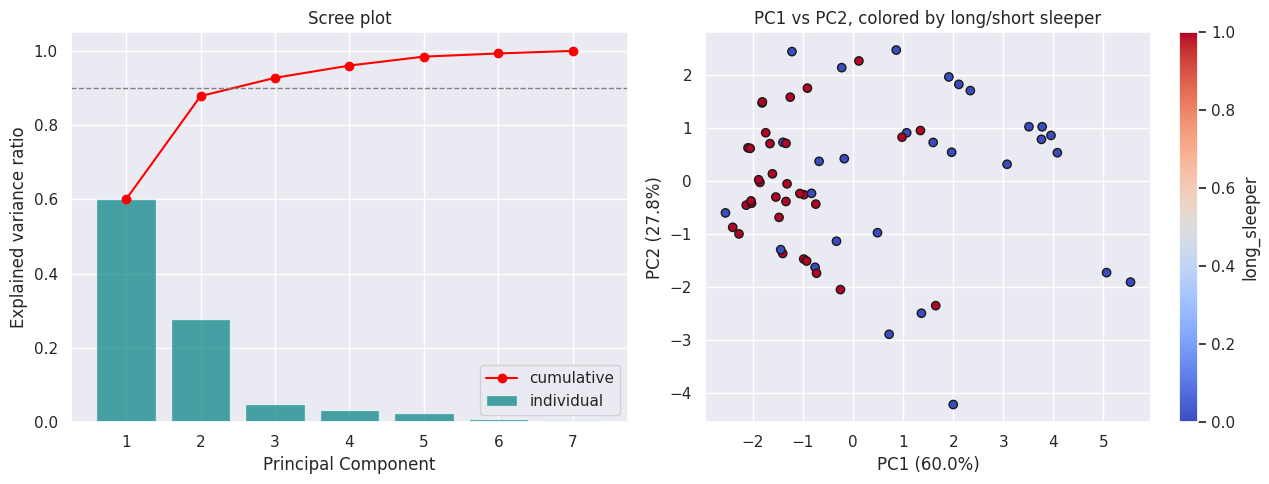


=== PCA loadings (PC1 / PC2) ===
                           PC1       PC2
log_body_weight       0.439198 -0.203171
log_brain_weight      0.433646 -0.265017
sleep_exposure_index  0.426593  0.233543
gestation_time        0.424117 -0.164853
max_life_span         0.324070 -0.401371
danger_index          0.317823  0.525487
predation_index       0.226200  0.607893

=== DONE — all figures saved as 01_...png through 07_...png ===


In [36]:
X_pca_input = model_df[predictors]
X_pca_scaled = StandardScaler().fit_transform(X_pca_input)

pca = PCA()
pca_scores = pca.fit_transform(X_pca_scaled)
explained = pca.explained_variance_ratio_

print("\n=== PCA explained variance ratio ===")
for i, v in enumerate(explained, 1):
    print(f"PC{i}: {v:.3f}  (cumulative: {explained[:i].sum():.3f})")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(range(1, len(explained) + 1), explained, color='teal', alpha=0.7, label='individual')
axes[0].plot(range(1, len(explained) + 1), np.cumsum(explained), color='red', marker='o', label='cumulative')
axes[0].axhline(0.9, color='gray', linestyle='--', lw=1)
axes[0].set_xlabel('Principal Component'); axes[0].set_ylabel('Explained variance ratio')
axes[0].set_title('Scree plot'); axes[0].legend()

scatter = axes[1].scatter(pca_scores[:, 0], pca_scores[:, 1], c=y_clf, cmap='coolwarm', edgecolor='k')
axes[1].set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
axes[1].set_title('PC1 vs PC2, colored by long/short sleeper')
plt.colorbar(scatter, ax=axes[1], label='long_sleeper')
plt.tight_layout()
plt.savefig('07_pca_scree_and_projection.png')
plt.show()

# Loadings — which original features drive PC1/PC2
loadings = pd.DataFrame(pca.components_[:2].T, index=predictors, columns=['PC1', 'PC2'])
print("\n=== PCA loadings (PC1 / PC2) ===")
print(loadings.sort_values('PC1', ascending=False))

print("\n=== DONE — all figures saved as 01_...png through 07_...png ===")

# Thank You